# Day 1: Python、Pandas 和 Matplotlib 基础

今天的目标：

- 熟悉 Jupyter Notebook 的基本运行方式。
- 会用 Pandas 创建、读取、查看和筛选表格数据。
- 会处理简单缺失值。
- 会用 Matplotlib 画直方图和散点图。

材料机器学习项目里，最常见的数据形式就是表格：每一行是一个材料，每一列是一个属性或特征。

In [3]:
import os
from pathlib import Path

# 避免 Matplotlib 在部分受限环境下写入默认缓存目录失败。
os.environ.setdefault("MPLCONFIGDIR", "../.matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 全局画图字体约定。
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Project root:", PROJECT_ROOT)

NumPy: 1.26.4
Pandas: 2.2.3
Project root: /mnt/d/桌面/AI—study/Day03


## 1. 创建一个小型材料数据表

下面用一个很小的示例数据集模拟材料带隙数据。真实项目中，我们会把这个小表换成 Matbench 或 Materials Project 的数据。

In [4]:
materials = pd.DataFrame({
    "formula": ["Si", "Ge", "GaAs", "TiO2", "ZnO", "Al2O3", "Fe", "Cu", "MoS2", "SnO2"],
    "band_gap_eV": [1.12, 0.67, 1.42, 3.20, 3.37, 8.80, 0.00, 0.00, 1.80, 3.60],
    "n_elements": [1, 1, 2, 2, 2, 2, 1, 1, 2, 2],
    "contains_oxygen": [0, 0, 0, 1, 1, 1, 0, 0, 0, 1],
    "structure_type": ["diamond", "diamond", "zincblende", "rutile", "wurtzite", "corundum", "bcc", "fcc", "layered", "rutile"]
})

materials

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
6,Fe,0.00,1,0,bcc
7,Cu,0.00,1,0,fcc
8,MoS2,1.80,2,0,layered
9,SnO2,3.60,2,1,rutile


## 2. 保存和读取 CSV

CSV 是最常见的数据文件格式之一。以后你从数据库下载、从 VASP 结果整理、或者从别人项目里拿到的数据，很可能都是 CSV。

In [5]:
csv_path = RAW_DATA_DIR / "day1_example_materials.csv"
materials.to_csv(csv_path, index=False)

df = pd.read_csv(csv_path)
df.head()

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite


## 3. 查看数据基本信息

In [6]:
df.info() # 打印 DataFrame 的简要摘要信息，让你快速了解数据的整体状况。

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   formula          10 non-null     object 
 1   band_gap_eV      10 non-null     float64
 2   n_elements       10 non-null     int64  
 3   contains_oxygen  10 non-null     int64  
 4   structure_type   10 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 528.0+ bytes


In [7]:
df.describe()  # 快速了解数值型列的基本统计信息，如均值、标准差、最小值、最大值、四分位数等。std 标准差

,band_gap_eV,n_elements,contains_oxygen
count,10.000000,10.000000,10.000000
mean,2.398000,1.600000,0.400000
std,2.613056,0.516398,0.516398
min,0.000000,1.000000,0.000000
25%,0.782500,1.000000,0.000000
50%,1.610000,2.000000,0.000000
75%,3.327500,2.000000,1.000000
max,8.800000,2.000000,1.000000


你需要重点关注：

- 数据有多少行？
- 哪些列是数字？
- `band_gap_eV` 的最小值、最大值、平均值是多少？

## 4. 选择列和筛选行

In [8]:
# 选择单列
df["band_gap_eV"]

0    1.12
1    0.67
2    1.42
3    3.20
4    3.37
5    8.80
6    0.00
7    0.00
8    1.80
9    3.60
Name: band_gap_eV, dtype: float64

In [9]:
# 选择多列
df[["formula", "band_gap_eV", "contains_oxygen"]]

,formula,band_gap_eV,contains_oxygen
0,Si,1.12,0
1,Ge,0.67,0
2,GaAs,1.42,0
3,TiO2,3.20,1
4,ZnO,3.37,1
5,Al2O3,8.80,1
6,Fe,0.00,0
7,Cu,0.00,0
8,MoS2,1.80,0
9,SnO2,3.60,1


In [10]:
# 筛选半导体或绝缘体：带隙大于 0
semiconductors = df[df["band_gap_eV"] > 0]
semiconductors

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
8,MoS2,1.80,2,0,layered
9,SnO2,3.60,2,1,rutile


In [11]:
# 筛选含氧材料
oxygen_materials = df[df["contains_oxygen"] == 1]
oxygen_materials

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
9,SnO2,3.60,2,1,rutile


## 5. 简单统计

这些统计不是机器学习模型，但能帮助你快速理解数据。材料项目中不要一上来就训练模型，先看数据。

In [12]:
print("材料数量:", len(df))
print("平均带隙:", df["band_gap_eV"].mean())
print("最大带隙:", df["band_gap_eV"].max())
print("最小带隙:", df["band_gap_eV"].min())
print("带隙大于 0 的材料数量:", (df["band_gap_eV"] > 0).sum())

材料数量: 10
平均带隙: 2.3980000000000006
最大带隙: 8.8
最小带隙: 0.0
带隙大于 0 的材料数量: 8


## 6. 缺失值处理

真实数据经常会有缺失值。这里人为制造一个缺失值，然后练习 `isna`、`dropna` 和 `fillna`。

In [13]:
df_missing = df.copy()
df_missing.loc[3, "band_gap_eV"] = np.nan
df_missing

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
3,TiO2,NaN,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
6,Fe,0.00,1,0,bcc
7,Cu,0.00,1,0,fcc
8,MoS2,1.80,2,0,layered
9,SnO2,3.60,2,1,rutile


In [14]:
df_missing.isna().sum()

formula            0
band_gap_eV        1
n_elements         0
contains_oxygen    0
structure_type     0
dtype: int64

In [15]:
# 方法 1：删除包含缺失标签的行
df_dropna = df_missing.dropna(subset=["band_gap_eV"])
df_dropna

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.12,1,0,diamond
1,Ge,0.67,1,0,diamond
2,GaAs,1.42,2,0,zincblende
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
6,Fe,0.00,1,0,bcc
7,Cu,0.00,1,0,fcc
8,MoS2,1.80,2,0,layered
9,SnO2,3.60,2,1,rutile


In [16]:
# 方法 2：用平均值填充。注意：真实建模时要谨慎使用，不能随便填标签。
df_fillna = df_missing.copy()
df_fillna["band_gap_eV"] = df_fillna["band_gap_eV"].fillna(df_fillna["band_gap_eV"].mean())
df_fillna

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
0,Si,1.120000,1,0,diamond
1,Ge,0.670000,1,0,diamond
2,GaAs,1.420000,2,0,zincblende
3,TiO2,2.308889,2,1,rutile
4,ZnO,3.370000,2,1,wurtzite
5,Al2O3,8.800000,2,1,corundum
6,Fe,0.000000,1,0,bcc
7,Cu,0.000000,1,0,fcc
8,MoS2,1.800000,2,0,layered
9,SnO2,3.600000,2,1,rutile


## 7. 画图：带隙分布直方图

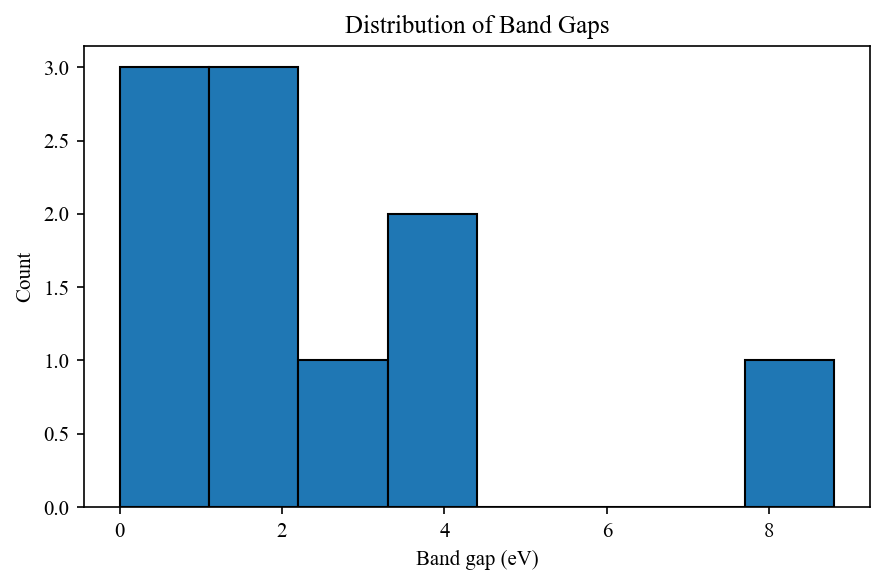

In [17]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.hist(df["band_gap_eV"], bins=8, edgecolor="black")
ax.set_xlabel("Band gap (eV)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Band Gaps")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day1_band_gap_hist.png", dpi=300)
plt.show()

## 8. 画图：元素种类数 vs 带隙

这个例子不代表真实物理规律，只是练习散点图。后面我们会用更多材料特征训练模型。

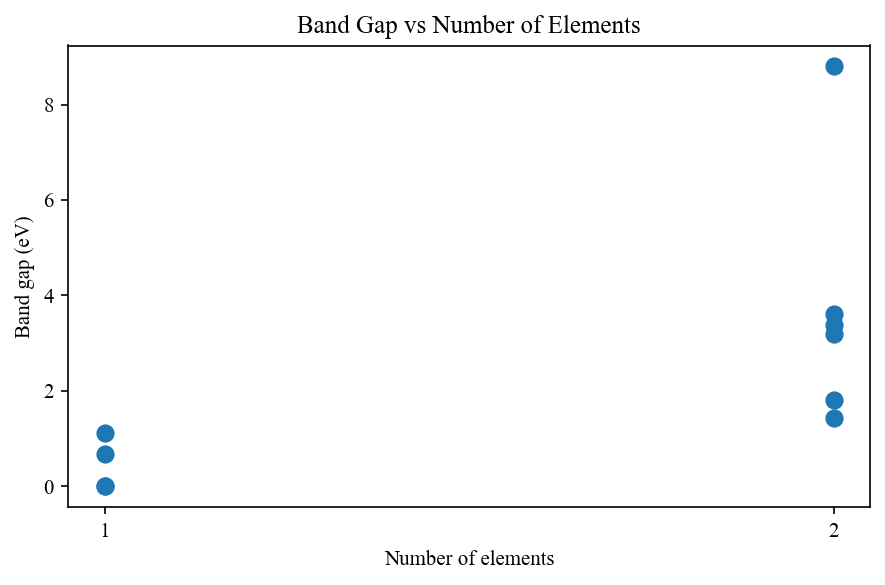

In [18]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.scatter(df["n_elements"], df["band_gap_eV"], s=60)
ax.set_xlabel("Number of elements")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Band Gap vs Number of Elements")
ax.set_xticks([1, 2])
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day1_gap_vs_n_elements.png", dpi=300)
plt.show()

## 9. 今日练习

请你自己完成下面几个小练习：

1. 筛选出 `band_gap_eV > 3` 的材料。
2. 计算含氧材料的平均带隙。
3. 找出带隙最大的材料名称。
4. 新增一列 `is_wide_gap`，当带隙大于 3 eV 时为 1，否则为 0。
5. 把筛选后的宽带隙材料保存到 `PROCESSED_DATA_DIR / "day1_wide_gap_materials.csv"`。

In [19]:
# 练习 1：筛选 band_gap_eV > 3 的材料

df_with_large_bandgap = df[df["band_gap_eV"] > 3]
df_with_large_bandgap

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
9,SnO2,3.60,2,1,rutile


In [20]:
# 练习 2：计算含氧材料的平均带隙
df_oxygen = df[df['contains_oxygen'] == 1]
average_bandgap_oxygen = df_oxygen.band_gap_eV.mean() # 列名必须是有效的 Python 标识符，例如：如果列名叫做mean就无效了
#average_bandgap_oxygen = df_oxygen['band_gap_eV'].mean()
average_bandgap_oxygen


4.742500000000001

In [21]:
# 练习 3：找出带隙最大的材料名称
raw_max_bandgap_material = df[df["band_gap_eV"] == df["band_gap_eV"].max()]
max_bandgap_material_name = raw_max_bandgap_material["formula"].values[0]
max_bandgap_material_name


'Al2O3'

In [26]:
# 练习 4：新增 is_wide_gap 列
df['is_wide_gap'] = (df['band_gap_eV'] > 3).astype(int)
df

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type,is_wide_gap
0,Si,1.12,1,0,diamond,0
1,Ge,0.67,1,0,diamond,0
2,GaAs,1.42,2,0,zincblende,0
3,TiO2,3.20,2,1,rutile,1
4,ZnO,3.37,2,1,wurtzite,1
5,Al2O3,8.80,2,1,corundum,1
6,Fe,0.00,1,0,bcc,0
7,Cu,0.00,1,0,fcc,0
8,MoS2,1.80,2,0,layered,0
9,SnO2,3.60,2,1,rutile,1


In [24]:
# 练习 5：保存宽带隙材料 CSV
df_with_large_bandgap.to_csv(PROCESSED_DATA_DIR / "wide_gap_materials.csv", index=False)
df_with_large_bandgap.head()

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type
3,TiO2,3.20,2,1,rutile
4,ZnO,3.37,2,1,wurtzite
5,Al2O3,8.80,2,1,corundum
9,SnO2,3.60,2,1,rutile


In [ ]:
# Pandas 常用筛选组合
df[(df["band_gap_eV"] > 3.3) & (df["structure_type"] == 'rutile')] # &表示并且 | 表示或者 

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type,is_wide_gap
9,SnO2,3.6,2,1,rutile,1


In [ ]:
# 排序
df.sort_values("band_gap_eV", ascending=False)  # 按带隙从大到小排序, ascending=True表示升序，False表示降序

,formula,band_gap_eV,n_elements,contains_oxygen,structure_type,is_wide_gap
5,Al2O3,8.80,2,1,corundum,1
9,SnO2,3.60,2,1,rutile,1
4,ZnO,3.37,2,1,wurtzite,1
3,TiO2,3.20,2,1,rutile,1
8,MoS2,1.80,2,0,layered,0
2,GaAs,1.42,2,0,zincblende,0
0,Si,1.12,1,0,diamond,0
1,Ge,0.67,1,0,diamond,0
7,Cu,0.00,1,0,fcc,0
6,Fe,0.00,1,0,bcc,0


In [31]:
# 分组统计
df.groupby("contains_oxygen")["band_gap_eV"].mean()  # 按是否含氧分组，计算平均带隙

contains_oxygen
0    0.8350
1    4.7425
Name: band_gap_eV, dtype: float64

In [32]:
df.groupby("structure_type")["band_gap_eV"].mean()  # 按结构类型分组，计算平均带隙

structure_type
bcc           0.000
corundum      8.800
diamond       0.895
fcc           0.000
layered       1.800
rutile        3.400
wurtzite      3.370
zincblende    1.420
Name: band_gap_eV, dtype: float64

## 10. 今日自查

完成后，请确认你能回答：

- `DataFrame` 是什么？
- `df.head()`、`df.info()`、`df.describe()` 分别看什么？
- 如何筛选带隙大于 0 的材料？
- `dropna` 和 `fillna` 有什么区别？
- 为什么做机器学习前要先看数据分布？